# Unzipping the data taken from Kaggle

In [1]:
!unzip -q /content/zipped_data.zip -d /content/dataset

# Loading the necessary libraries

In [2]:
!pip install ultralytics
import cv2
import torch
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Function for Training the Model

In [3]:
def train_model():
    model = YOLO('yolov8n.pt')
    model.train(data='/content/dataset/data.yaml', epochs=30, imgsz=640, plots=True)
    print("Training complete")
    return model

# Function for space monitoring

In [4]:
def run_space_monitor(image_path, model_path):
    model = YOLO(model_path)
    results = model(image_path)[0]

    img = cv2.imread(image_path)
    detections = []

    for box in results.boxes:
        coords = box.xyxy[0].tolist()
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        conf = float(box.conf[0])
        detections.append({'label': label, 'bbox': coords})

        cv2.rectangle(img, (int(coords[0]), int(coords[1])), (int(coords[2]), int(coords[3])), (0, 255, 0), 2)
        cv2.putText(img, f"{label} {conf:.2f}", (int(coords[0]), int(coords[1]-10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    debris_list = [d for d in detections if d['label'] == 'debris']
    sat_list = [d for d in detections if 'sat' in d['label'] or d['label'] in ['soho', 'cheops', 'xmm_newton']]

    for d in debris_list:
        for s in sat_list:
            c1 = ((d['bbox'][0] + d['bbox'][2])/2, (d['bbox'][1] + d['bbox'][3])/2)
            c2 = ((s['bbox'][0] + s['bbox'][2])/2, (s['bbox'][1] + s['bbox'][3])/2)

            dist = ((c2[0] - c1[0])**2 + (c2[1] - c1[1])**2)**0.5

            color = (0, 0, 255) if dist < 150 else (0, 255, 255)
            cv2.line(img, (int(c1[0]), int(c1[1])), (int(c2[0]), int(c2[1])), color, 2)

            if dist < 150:
                cv2.putText(img, "WARNING: COLLISION RISK", (50, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

    cv2_imshow(img)

# Training the model

In [5]:
my_model = train_model()

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

# Labels we can predict

In [13]:
print(my_model.names)

{0: 'cheops', 1: 'debris', 2: 'double_start', 3: 'earth_observation_sat_1', 4: 'lisa_pathfinder', 5: 'proba_2', 6: 'proba_3_csc', 7: 'proba_3_ocs', 8: 'smart_1', 9: 'soho', 10: 'xmm_newton'}


# Testing


image 1/1 /content/dataset/test/images/img101184_jpg.rf.9c5bbe39a02acfe4c509e896a208c02a.jpg: 640x640 1 xmm_newton, 7.8ms
Speed: 1.7ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


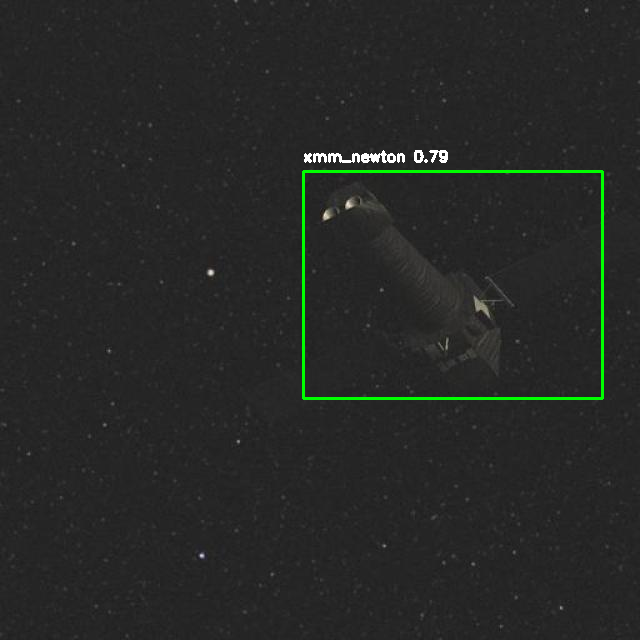

In [14]:
run_space_monitor('/content/dataset/test/images/img101184_jpg.rf.9c5bbe39a02acfe4c509e896a208c02a.jpg', '/content/runs/detect/train/weights/best.pt')


image 1/1 /content/dataset/test/images/img081296_jpg.rf.39c0b942a9a65dd39b1a5647fae6eb1b.jpg: 640x640 1 smart_1, 19.0ms
Speed: 3.0ms preprocess, 19.0ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


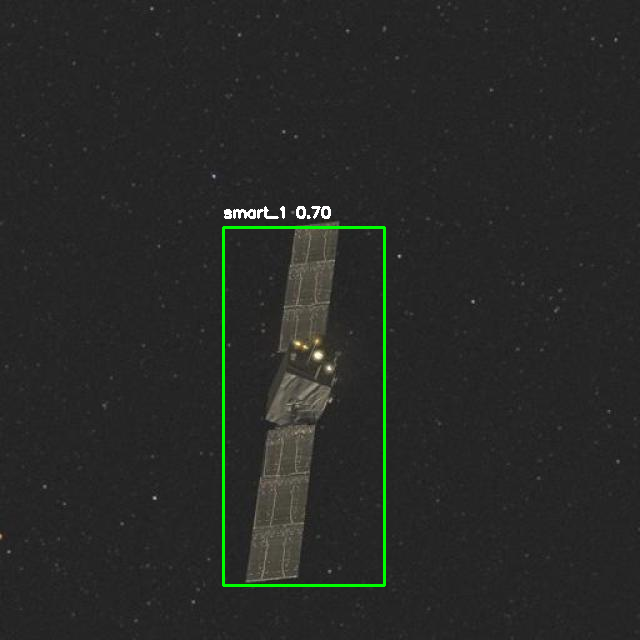

In [9]:
run_space_monitor('/content/dataset/test/images/img081296_jpg.rf.39c0b942a9a65dd39b1a5647fae6eb1b.jpg', '/content/runs/detect/train/weights/best.pt')


image 1/1 /content/dataset/test/images/img021927_jpg.rf.91830c181251b09d0664c76dbafb9d5c.jpg: 640x640 2 debriss, 12.6ms
Speed: 2.3ms preprocess, 12.6ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


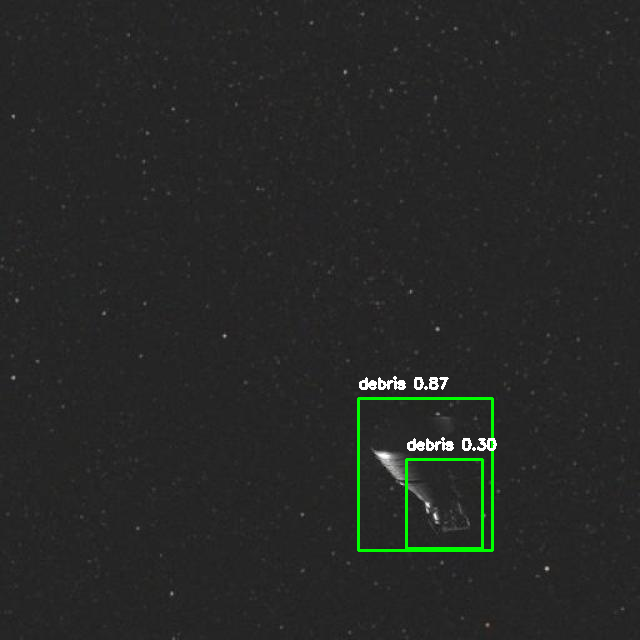

In [39]:
run_space_monitor('/content/dataset/test/images/img021927_jpg.rf.91830c181251b09d0664c76dbafb9d5c.jpg', '/content/runs/detect/train/weights/best.pt')

# Evaluation

In [41]:
metrics = my_model.val(data='/content/dataset/data.yaml', split='test')

print(f"Mean Average Precision (mAP50): {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Precision: {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Recall: {metrics.results_dict['metrics/recall(B)']:.4f}")

Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 417.6±246.0 MB/s, size: 29.0 KB)
val: Scanning /content/dataset/test/labels... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 1.1Kit/s 0.1s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2it/s 3.7s
                   all        123        123       0.91      0.824        0.9      0.511
                cheops         11         11       0.94          1      0.995      0.677
                debris         11         11      0.896      0.636      0.831       0.49
          double_start         12         12          1      0.954      0.995      0.567
earth_observation_sat_1         11         11      0.777      0.727      0.783      0.361
  